<a href="https://colab.research.google.com/github/MOHAMMAD-Ghouse/Machine-Learning-on-Big-Data-Portfolio/blob/main/Week_9_News_Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark -q

import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml.feature import (
    RegexTokenizer,
    StopWordsRemover,
    HashingTF,
    IDF
)

from pyspark.ml.classification import (
    LogisticRegression,
    LinearSVC
)

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

spark = (
    SparkSession.builder
    .appName("NewsTextClassification")
    .getOrCreate()
)

print("Spark Version:", spark.version)

Spark Version: 4.0.4


In [2]:
DATA_PATH = "/content/test.csv"

df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(DATA_PATH)
)

print("Total Rows:", df.count())
print("Total Columns:", len(df.columns))

df.show(5, truncate=100)

Total Rows: 7600
Total Columns: 3
+-----------+--------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------+
|Class Index|                                                                                 Title|                                                                                         Description|
+-----------+--------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------+
|          3|                                                     Fears for T N pension after talks|Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stric...|
|          4|The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com)|SPACE.com - TORONTO, Canada -- A second\team of rocketeers

In [3]:
print("Dataset Schema:")
df.printSchema()

print("\nClass Distribution:")
df.groupBy("Class Index") \
  .count() \
  .orderBy("Class Index") \
  .show()

# Remove missing values
df_clean = df.dropna()

# Combine Title and Description
df_text = df_clean.withColumn(
    "text",
    F.concat_ws(
        " ",
        F.col("Title"),
        F.col("Description")
    )
)

print("Rows after cleaning:", df_text.count())

df_text.select(
    "Class Index",
    "text"
).show(5, truncate=100)

Dataset Schema:
root
 |-- Class Index: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Description: string (nullable = true)


Class Distribution:
+-----------+-----+
|Class Index|count|
+-----------+-----+
|          1| 1900|
|          2| 1900|
|          3| 1900|
|          4| 1900|
+-----------+-----+

Rows after cleaning: 7600
+-----------+----------------------------------------------------------------------------------------------------+
|Class Index|                                                                                                text|
+-----------+----------------------------------------------------------------------------------------------------+
|          3|Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'di...|
|          4|The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com) SPACE.com ...|
|          4|Ky. Company Wins Grant to Study Peptides (AP) AP - A compa

In [4]:
tokenizer = RegexTokenizer(
    inputCol="text",
    outputCol="words",
    pattern="\\W+"
)

tokenized = tokenizer.transform(df_text)

remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words"
)

clean_text = remover.transform(tokenized)

hashing_tf = HashingTF(
    inputCol="filtered_words",
    outputCol="raw_features",
    numFeatures=5000
)

tf_data = hashing_tf.transform(clean_text)

idf = IDF(
    inputCol="raw_features",
    outputCol="features"
)

idf_model = idf.fit(tf_data)

data = idf_model.transform(tf_data)

data.select(
    "Class Index",
    "features"
).show(5, truncate=False)

+-----------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|Class Index|features                                                                                                                                                                                                                                    

In [7]:
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier
)

from pyspark.ml.evaluation import MulticlassClassificationEvaluator


# Train/Test Split
train_data, test_data = data.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training Records:", train_data.count())
print("Testing Records:", test_data.count())


# Logistic Regression
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=50
)

lr_model = lr.fit(train_data)

lr_predictions = lr_model.transform(test_data)


# Random Forest Classifier
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=50,
    maxDepth=10,
    seed=42
)

rf_model = rf.fit(train_data)

rf_predictions = rf_model.transform(test_data)


# Accuracy Evaluation
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

lr_accuracy = evaluator.evaluate(lr_predictions)
rf_accuracy = evaluator.evaluate(rf_predictions)

print("Logistic Regression Accuracy:", round(lr_accuracy, 4))
print("Random Forest Accuracy:", round(rf_accuracy, 4))

Training Records: 6150
Testing Records: 1450
Logistic Regression Accuracy: 0.7462
Random Forest Accuracy: 0.7117


+-------------------+------------------+
|              Model|          Accuracy|
+-------------------+------------------+
|Logistic Regression|0.7462068965517241|
|      Random Forest|0.7117241379310345|
+-------------------+------------------+



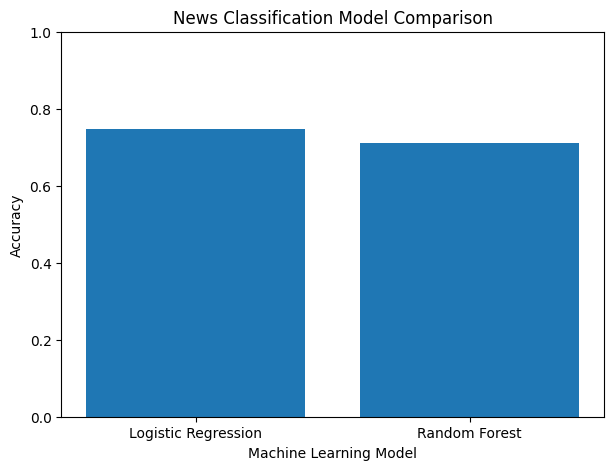


WEEK 9 — NEWS TEXT CLASSIFICATION USING PYSPARK

PROJECT COMPLETED SUCCESSFULLY

DATA PROCESSING:
• Text cleaning
• Tokenisation
• Stop-word removal
• TF-IDF feature extraction

MACHINE LEARNING MODELS:
• Logistic Regression
• Random Forest Classifier

MODEL EVALUATION:
• Train/Test Split
• Accuracy comparison

CONCLUSION:
News articles were processed and transformed into
TF-IDF features using PySpark. Two multi-class
machine learning models were trained to classify
news articles into different categories.

WEEK 9 COMPLETE



In [8]:
results = [
    ("Logistic Regression", float(lr_accuracy)),
    ("Random Forest", float(rf_accuracy))
]

results_df = spark.createDataFrame(
    results,
    ["Model", "Accuracy"]
)

results_df.show()


results_pd = results_df.toPandas()

plt.figure(figsize=(7, 5))

plt.bar(
    results_pd["Model"],
    results_pd["Accuracy"]
)

plt.title("News Classification Model Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)
plt.show()


print("""
====================================================
WEEK 9 — NEWS TEXT CLASSIFICATION USING PYSPARK
====================================================

PROJECT COMPLETED SUCCESSFULLY

DATA PROCESSING:
• Text cleaning
• Tokenisation
• Stop-word removal
• TF-IDF feature extraction

MACHINE LEARNING MODELS:
• Logistic Regression
• Random Forest Classifier

MODEL EVALUATION:
• Train/Test Split
• Accuracy comparison

CONCLUSION:
News articles were processed and transformed into
TF-IDF features using PySpark. Two multi-class
machine learning models were trained to classify
news articles into different categories.

====================================================
WEEK 9 COMPLETE
====================================================
""")